# Chapter 04 Regression Modeling: rendered figures

Executed preview for browsing on GitHub (static image output, since GitHub's notebook viewer cannot run the interactive JS the live book uses). The source of truth for regenerating the book's figures is `chapter-04-regression-modeling-plots.py`. Run that script directly, not this notebook, to update `_generated/`.

In [1]:
"""
Interactive figures for Chapter 4: Regression Modeling.

Same pattern as prior chapters: each function builds one self-contained, standalone Plotly
HTML page and writes it to ../_generated/. Run directly to regenerate every figure:
    python3 chapter-04-regression-modeling-plots.py
"""

import os

import numpy as np
import plotly.graph_objects as go
from scipy import stats

RNG = np.random.default_rng(23)
OUT_DIR = os.path.join(os.path.dirname(os.path.abspath(__file__)), "..", "_generated")
os.makedirs(OUT_DIR, exist_ok=True)


def save(fig: go.Figure, name: str) -> str:
    path = os.path.join(OUT_DIR, f"{name}.html")
    fig.write_html(path, include_plotlyjs="cdn", full_html=True)
    return path


def payload_latency_sample(n: int, noise_sd: float, seed_offset: int = 0):
    rng = np.random.default_rng(23 + seed_offset)
    payload_kb = rng.uniform(2, 20, size=n)
    latency_ms = 25 + 9 * payload_kb + rng.normal(0, noise_sd, size=n)
    return payload_kb, latency_ms


# ---------------------------------------------------------------------------
# Figure 1: OLS fit as noise level changes
# ---------------------------------------------------------------------------
def fig_ols_fit() -> go.Figure:
    noise_levels = [5, 15, 30, 50, 80]
    frames = []
    x_line = np.linspace(2, 20, 50)
    for noise in noise_levels:
        x, y = payload_latency_sample(150, noise)
        slope, intercept, r, p, se = stats.linregress(x, y)
        y_line = intercept + slope * x_line
        frames.append(
            go.Frame(
                name=str(noise),
                data=[
                    go.Scatter(x=x, y=y, mode="markers", marker=dict(color="#4C78A8", size=6, opacity=0.55)),
                    go.Scatter(x=x_line, y=y_line, mode="lines", line=dict(color="#E45756", width=3)),
                ],
                layout=go.Layout(annotations=[dict(
                    x=0.02, y=0.95, xref="paper", yref="paper", showarrow=False,
                    text=f"R-squared = {r**2:.2f}", font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="An OLS fit of latency on payload size as noise grows",
        xaxis_title="payload size (KB)",
        yaxis_title="latency (ms)",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "noise standard deviation (ms): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 2: confidence interval vs. prediction interval as sample size grows
# ---------------------------------------------------------------------------
def fig_ci_vs_pi() -> go.Figure:
    sample_sizes = [10, 25, 50, 150, 500]
    x_grid = np.linspace(2, 20, 60)
    frames = []
    for n in sample_sizes:
        x, y = payload_latency_sample(n, 30)
        slope, intercept, r, p, se = stats.linregress(x, y)
        y_hat = intercept + slope * x
        resid = y - y_hat
        s = np.sqrt(np.sum(resid ** 2) / (n - 2))
        x_bar = x.mean()
        sxx = np.sum((x - x_bar) ** 2)
        t_val = stats.t.ppf(0.975, df=n - 2)

        y_line = intercept + slope * x_grid
        se_mean = s * np.sqrt(1 / n + (x_grid - x_bar) ** 2 / sxx)
        se_pred = s * np.sqrt(1 + 1 / n + (x_grid - x_bar) ** 2 / sxx)
        ci_lo, ci_hi = y_line - t_val * se_mean, y_line + t_val * se_mean
        pi_lo, pi_hi = y_line - t_val * se_pred, y_line + t_val * se_pred

        frames.append(
            go.Frame(
                name=str(n),
                data=[
                    go.Scatter(x=np.concatenate([x_grid, x_grid[::-1]]),
                               y=np.concatenate([pi_hi, pi_lo[::-1]]),
                               fill="toself", fillcolor="rgba(76,120,168,0.15)",
                               line=dict(width=0), name="95% prediction interval"),
                    go.Scatter(x=np.concatenate([x_grid, x_grid[::-1]]),
                               y=np.concatenate([ci_hi, ci_lo[::-1]]),
                               fill="toself", fillcolor="rgba(228,87,86,0.35)",
                               line=dict(width=0), name="95% confidence interval"),
                    go.Scatter(x=x_grid, y=y_line, mode="lines",
                               line=dict(color="#333", width=2), name="fitted line"),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="The confidence interval narrows with sample size; the prediction interval "
              "barely does",
        xaxis_title="payload size (KB)",
        yaxis_title="latency (ms)",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "sample size (n): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 3: logistic regression, probability of a timeout as load rises
# ---------------------------------------------------------------------------
def fig_logistic_timeout() -> go.Figure:
    steepness_options = [0.05, 0.15, 0.3, 0.6, 1.0]
    load = np.linspace(0, 100, 300)
    midpoint = 60
    rng = np.random.default_rng(31)
    load_obs = rng.uniform(0, 100, 200)
    frames = []
    for k in steepness_options:
        p = 1 / (1 + np.exp(-k * (load - midpoint)))
        p_obs = 1 / (1 + np.exp(-k * (load_obs - midpoint)))
        outcome_obs = (rng.uniform(size=len(load_obs)) < p_obs).astype(float)
        frames.append(
            go.Frame(
                name=f"{k:.2f}",
                data=[
                    go.Scatter(x=load_obs, y=outcome_obs, mode="markers",
                               marker=dict(color="#72B7B2", size=6, opacity=0.5),
                               name="observed timeout (0/1)"),
                    go.Scatter(x=load, y=p, mode="lines",
                               line=dict(color="#E45756", width=3),
                               name="P(timeout)"),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="Logistic regression: probability of a timeout as concurrent load rises",
        xaxis_title="concurrent load (%)",
        yaxis_title="P(timeout)",
        yaxis_range=[-0.05, 1.05],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "steepness of the logistic curve: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 4: R-squared vs. adjusted R-squared as noise predictors are added
# ---------------------------------------------------------------------------
def fig_r2_vs_adjusted() -> go.Figure:
    n = 40
    x, y = payload_latency_sample(n, 30, seed_offset=5)
    rng = np.random.default_rng(41)
    noise_predictors = rng.normal(size=(n, 20))

    max_k = list(range(0, 21))
    frames = []
    r2_series, adj_r2_series = [], []
    for k in max_k:
        X = np.column_stack([np.ones(n), x, noise_predictors[:, :k]])
        beta, *_ = np.linalg.lstsq(X, y, rcond=None)
        y_hat = X @ beta
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        p = X.shape[1] - 1
        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
        r2_series.append(r2)
        adj_r2_series.append(adj_r2)
        frames.append(
            go.Frame(
                name=str(k),
                data=[
                    go.Scatter(x=max_k[: k + 1], y=r2_series, mode="lines+markers",
                               line=dict(color="#4C78A8", width=3), name="R-squared"),
                    go.Scatter(x=max_k[: k + 1], y=adj_r2_series, mode="lines+markers",
                               line=dict(color="#E45756", width=3), name="Adjusted R-squared"),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="R-squared always rises as predictors are added; adjusted R-squared does not",
        xaxis_title="number of random noise predictors added to the model",
        yaxis_title="value",
        xaxis_range=[0, 20],
        yaxis_range=[0, 1],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "noise predictors added: "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 5: Lasso vs. Ridge coefficient paths as regularization strength grows
# ---------------------------------------------------------------------------
def soft_threshold(z: float, lam: float) -> float:
    return np.sign(z) * max(abs(z) - lam, 0.0)


def lasso_coordinate_descent(X: np.ndarray, y: np.ndarray, lam: float, n_iter: int = 300) -> np.ndarray:
    n, p = X.shape
    beta = np.zeros(p)
    col_norms = np.sum(X ** 2, axis=0)
    for _ in range(n_iter):
        for j in range(p):
            residual = y - X @ beta + X[:, j] * beta[j]
            z = X[:, j] @ residual
            beta[j] = soft_threshold(z, lam * n) / col_norms[j] if col_norms[j] > 0 else 0.0
    return beta


def ridge_closed_form(X: np.ndarray, y: np.ndarray, lam: float) -> np.ndarray:
    p = X.shape[1]
    return np.linalg.solve(X.T @ X + lam * np.eye(p), X.T @ y)


def fig_regularization_paths() -> go.Figure:
    n = 60
    rng = np.random.default_rng(51)
    payload = rng.uniform(2, 20, n)
    region_a = rng.normal(size=n) * 0.5 + payload * 0.3   # correlated with payload
    region_b = rng.normal(size=n) * 0.5 + payload * 0.25  # also correlated with payload
    time_of_day = rng.normal(size=n)                       # unrelated noise feature
    endpoint_flag = rng.normal(size=n) * 0.3 + payload * 0.1

    X_raw = np.column_stack([payload, region_a, region_b, time_of_day, endpoint_flag])
    X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
    true_beta = np.array([9.0, 3.0, 2.5, 0.0, 1.0])
    y = X_raw @ true_beta + rng.normal(0, 15, size=n)
    y = y - y.mean()

    lambdas = [0.01, 0.5, 2, 8, 25, 60]
    feature_names = ["payload size", "region A", "region B", "time of day", "endpoint"]

    frames = []
    for lam in lambdas:
        lasso_beta = lasso_coordinate_descent(X, y, lam=lam / n)
        ridge_beta = ridge_closed_form(X, y, lam=lam)
        frames.append(
            go.Frame(
                name=f"{lam:g}",
                data=[
                    go.Bar(x=feature_names, y=lasso_beta, name="Lasso", marker_color="#E45756"),
                    go.Bar(x=feature_names, y=ridge_beta, name="Ridge", marker_color="#4C78A8"),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        barmode="group",
        title="Lasso drives correlated and irrelevant coefficients to zero; "
              "Ridge only shrinks them",
        yaxis_title="coefficient value",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "regularization strength (lambda): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=70, l=60, r=30, b=50),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 6: Ridge regression as a Gaussian prior, posterior narrowing as the
# prior variance shrinks (equivalently, as the Ridge penalty strengthens)
# ---------------------------------------------------------------------------
def fig_bayesian_ridge() -> go.Figure:
    x, y = payload_latency_sample(150, 30, seed_offset=9)
    x_c = x - x.mean()
    y_c = y - y.mean()
    slope, intercept, r, p, se = stats.linregress(x, y)
    resid = y_c - slope * x_c
    sigma2 = np.sum(resid ** 2) / (len(x) - 2)
    S = np.sum(x_c ** 2)
    b = np.sum(x_c * y_c)

    prior_variances = [1e6, 50, 10, 3, 1, 0.3]
    beta_grid = np.linspace(-2, 16, 400)
    frames = []
    for tau2 in prior_variances:
        precision = S / sigma2 + 1 / tau2
        post_mean = (b / sigma2) / precision
        post_sd = np.sqrt(1 / precision)
        implied_lambda = sigma2 / tau2
        density = stats.norm.pdf(beta_grid, loc=post_mean, scale=post_sd)
        frames.append(
            go.Frame(
                name=f"{tau2:g}",
                data=[
                    go.Scatter(x=beta_grid, y=density, mode="lines",
                               line=dict(color="#4C78A8", width=3), fill="tozeroy",
                               fillcolor="rgba(76,120,168,0.2)", name="posterior"),
                ],
                layout=go.Layout(annotations=[dict(
                    x=0.02, y=0.95, xref="paper", yref="paper", showarrow=False,
                    align="left",
                    text=(f"posterior mean = {post_mean:.2f}<br>"
                          f"posterior sd = {post_sd:.2f}<br>"
                          f"implied Ridge λ = {implied_lambda:.2f}"),
                    font=dict(size=13, color="#333"),
                )]),
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        title="A tighter Gaussian prior on the slope is Ridge regression: the posterior "
              "narrows and shrinks toward zero",
        xaxis_title="coefficient on payload size (beta)",
        yaxis_title="posterior density",
        xaxis_range=[-2, 16],
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "prior variance on beta (tau-squared): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


# ---------------------------------------------------------------------------
# Figure 7: AIC vs. BIC across three candidate models, as sample size grows
# ---------------------------------------------------------------------------
def fig_aic_bic() -> go.Figure:
    rng = np.random.default_rng(61)
    n_max = 400
    payload = rng.uniform(2, 20, n_max)
    region = rng.normal(size=n_max)
    time_of_day = rng.normal(size=n_max)
    true_latency = 25 + 9 * payload + 6 * region + rng.normal(0, 20, n_max)

    model_specs = [
        ("payload only", [payload]),
        ("payload + region", [payload, region]),
        ("payload + region + time of day", [payload, region, time_of_day]),
    ]

    sample_sizes = [30, 60, 120, 250, 400]
    frames = []
    for n in sample_sizes:
        aic_vals, bic_vals = [], []
        y = true_latency[:n]
        for _, predictors in model_specs:
            X = np.column_stack([np.ones(n)] + [p[:n] for p in predictors])
            beta, *_ = np.linalg.lstsq(X, y, rcond=None)
            resid = y - X @ beta
            k = X.shape[1]
            sigma2 = np.sum(resid ** 2) / n
            log_lik = -0.5 * n * (np.log(2 * np.pi * sigma2) + 1)
            aic_vals.append(-2 * log_lik + 2 * k)
            bic_vals.append(-2 * log_lik + k * np.log(n))

        labels = [name for name, _ in model_specs]
        frames.append(
            go.Frame(
                name=str(n),
                data=[
                    go.Bar(x=labels, y=aic_vals, name="AIC", marker_color="#4C78A8"),
                    go.Bar(x=labels, y=bic_vals, name="BIC", marker_color="#E45756"),
                ],
            )
        )

    fig = go.Figure(data=frames[0].data, frames=frames, layout=frames[0].layout)
    fig.update_layout(
        barmode="group",
        title="AIC and BIC across three candidate models, as sample size grows",
        yaxis_title="information criterion (lower is better)",
        sliders=[{
            "active": 0,
            "currentvalue": {"prefix": "sample size (n): "},
            "steps": [
                {"label": f.name, "method": "animate",
                 "args": [[f.name], {"mode": "immediate", "frame": {"duration": 300}}]}
                for f in frames
            ],
        }],
        margin=dict(t=60, l=60, r=30, b=50),
    )
    return fig


FIGURES = {
    "chapter-04-fig-ols-fit": fig_ols_fit,
    "chapter-04-fig-ci-vs-pi": fig_ci_vs_pi,
    "chapter-04-fig-logistic-timeout": fig_logistic_timeout,
    "chapter-04-fig-r2-vs-adjusted": fig_r2_vs_adjusted,
    "chapter-04-fig-aic-bic": fig_aic_bic,
    "chapter-04-fig-regularization-paths": fig_regularization_paths,
    "chapter-04-fig-bayesian-ridge": fig_bayesian_ridge,
}


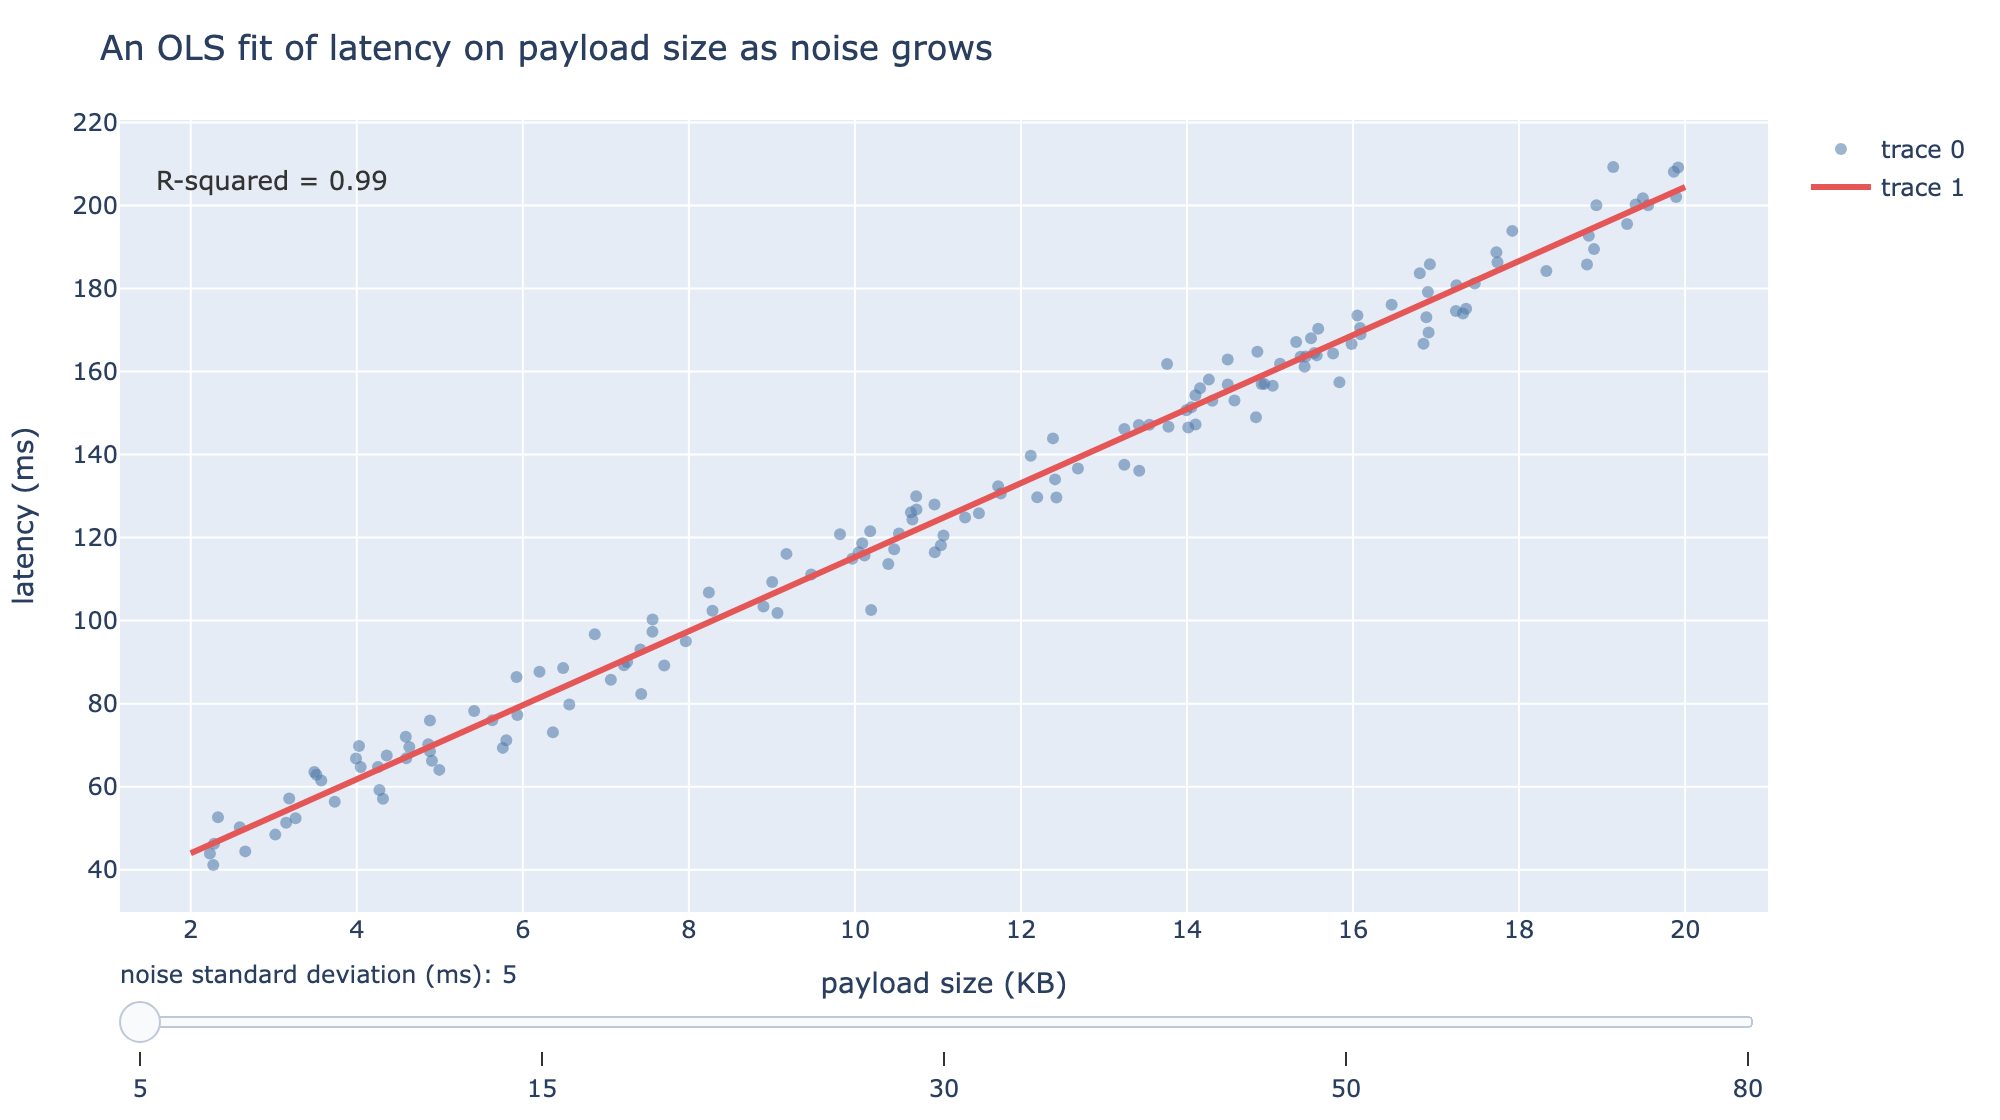

In [2]:
fig = FIGURES["chapter-04-fig-ols-fit"]()
fig

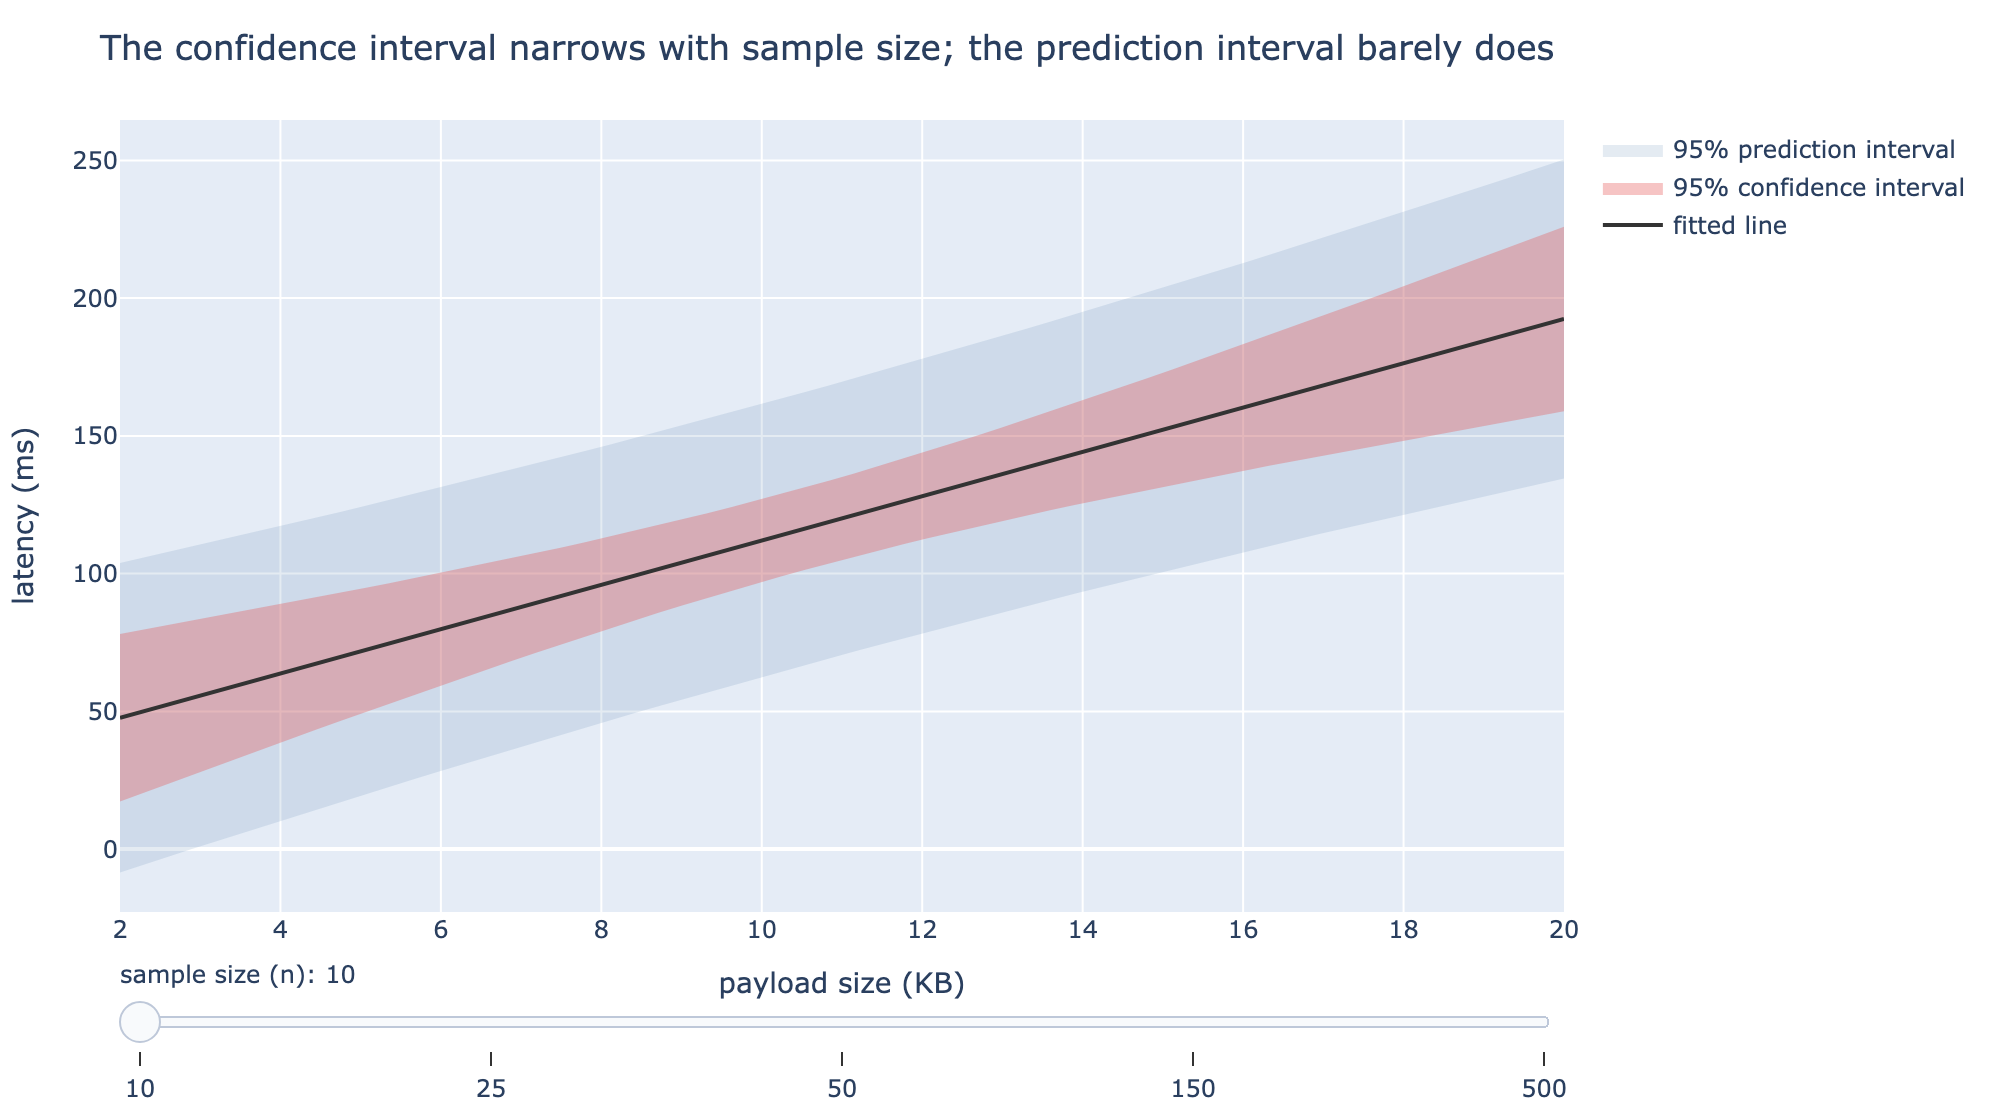

In [3]:
fig = FIGURES["chapter-04-fig-ci-vs-pi"]()
fig

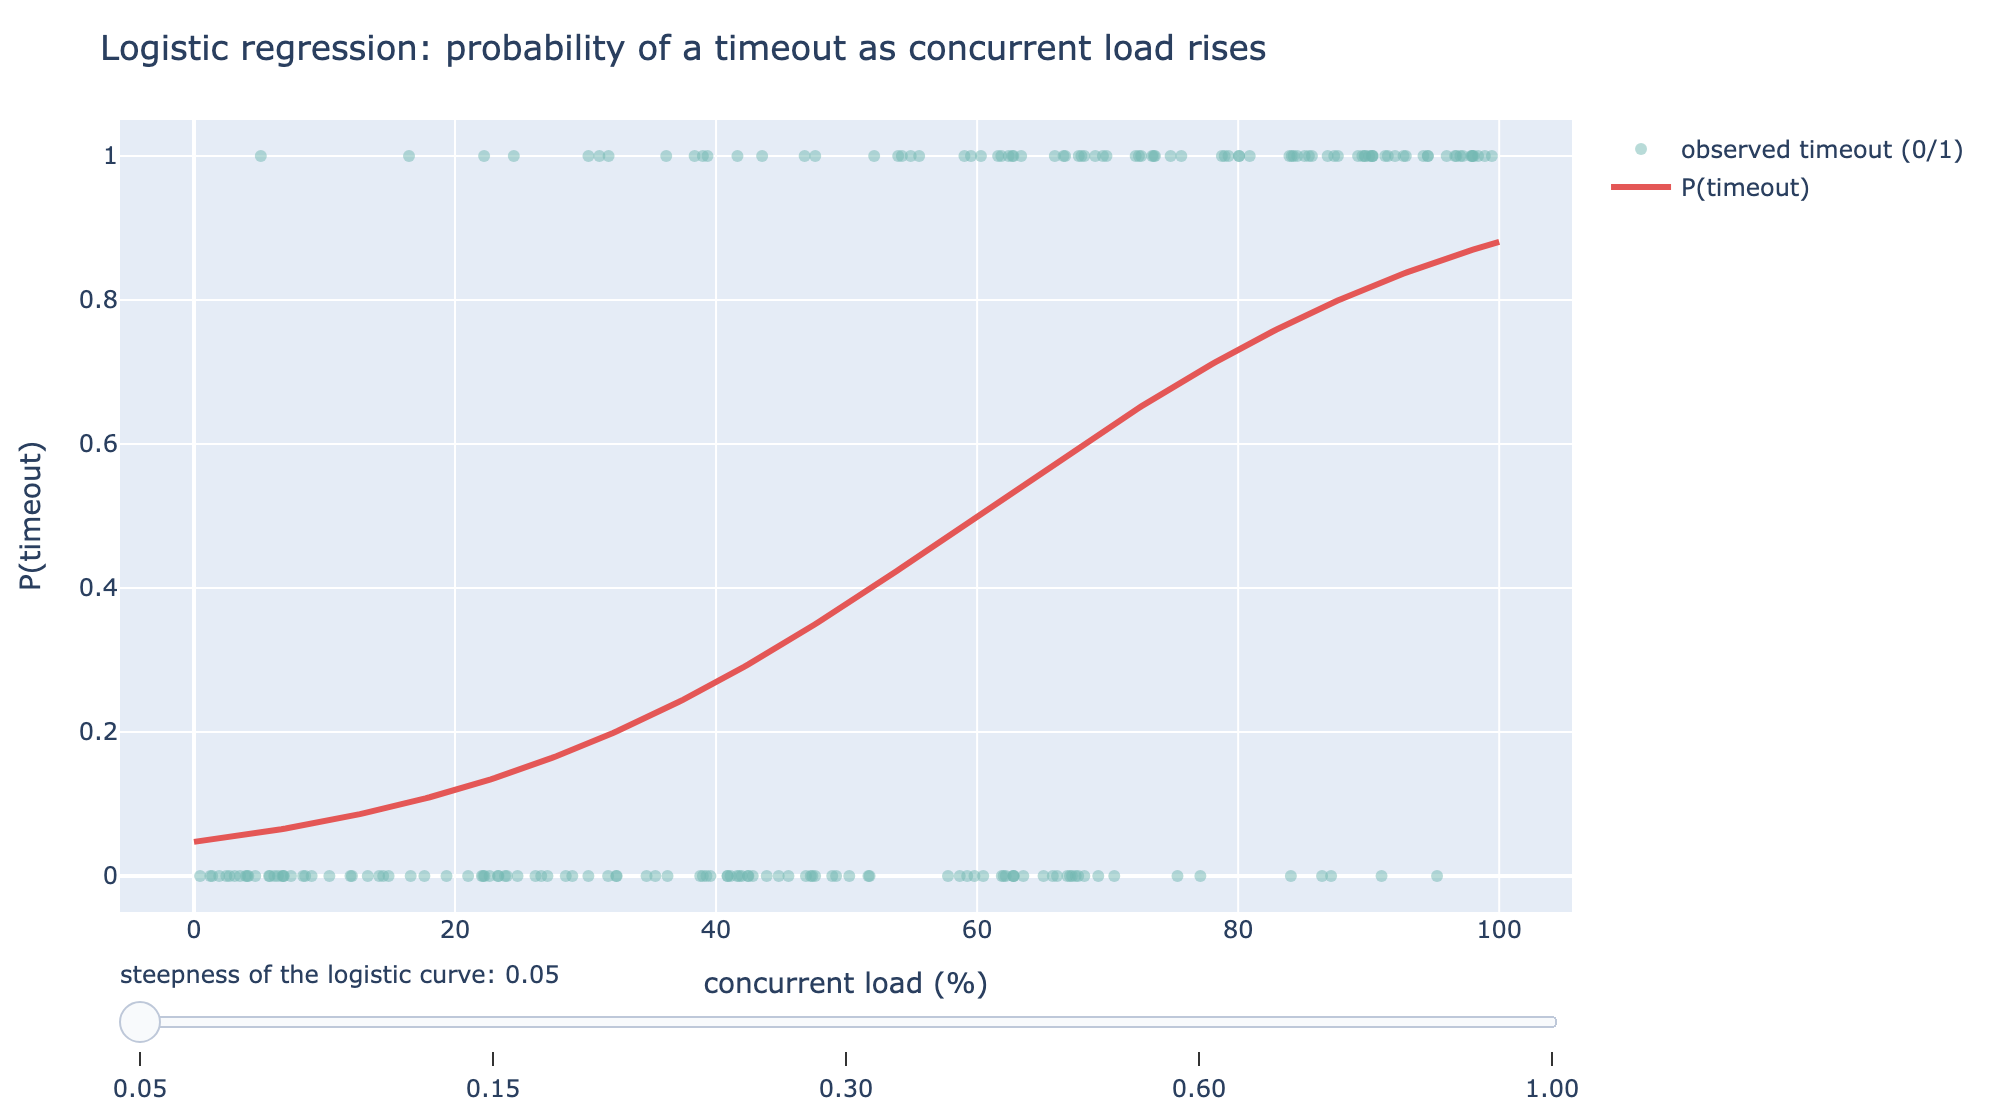

In [4]:
fig = FIGURES["chapter-04-fig-logistic-timeout"]()
fig

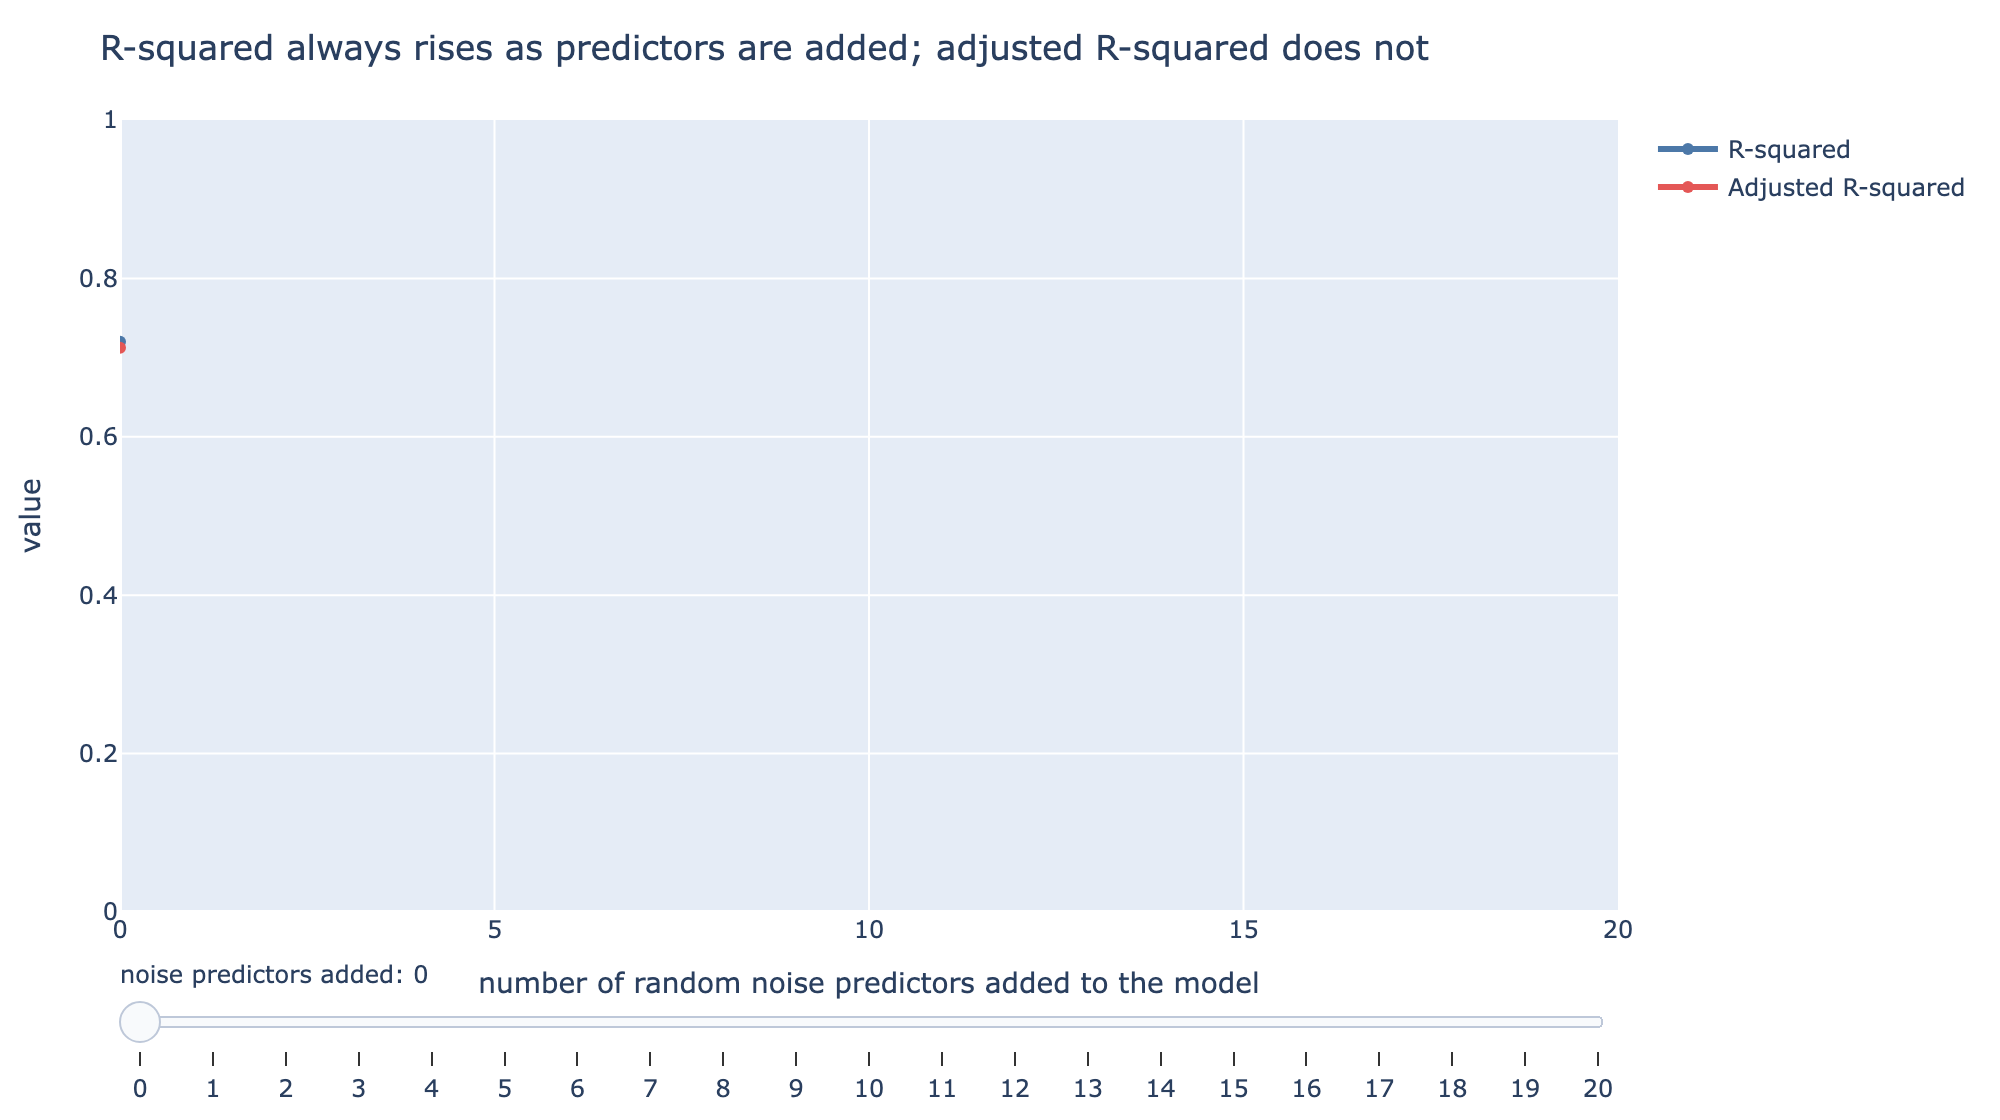

In [5]:
fig = FIGURES["chapter-04-fig-r2-vs-adjusted"]()
fig

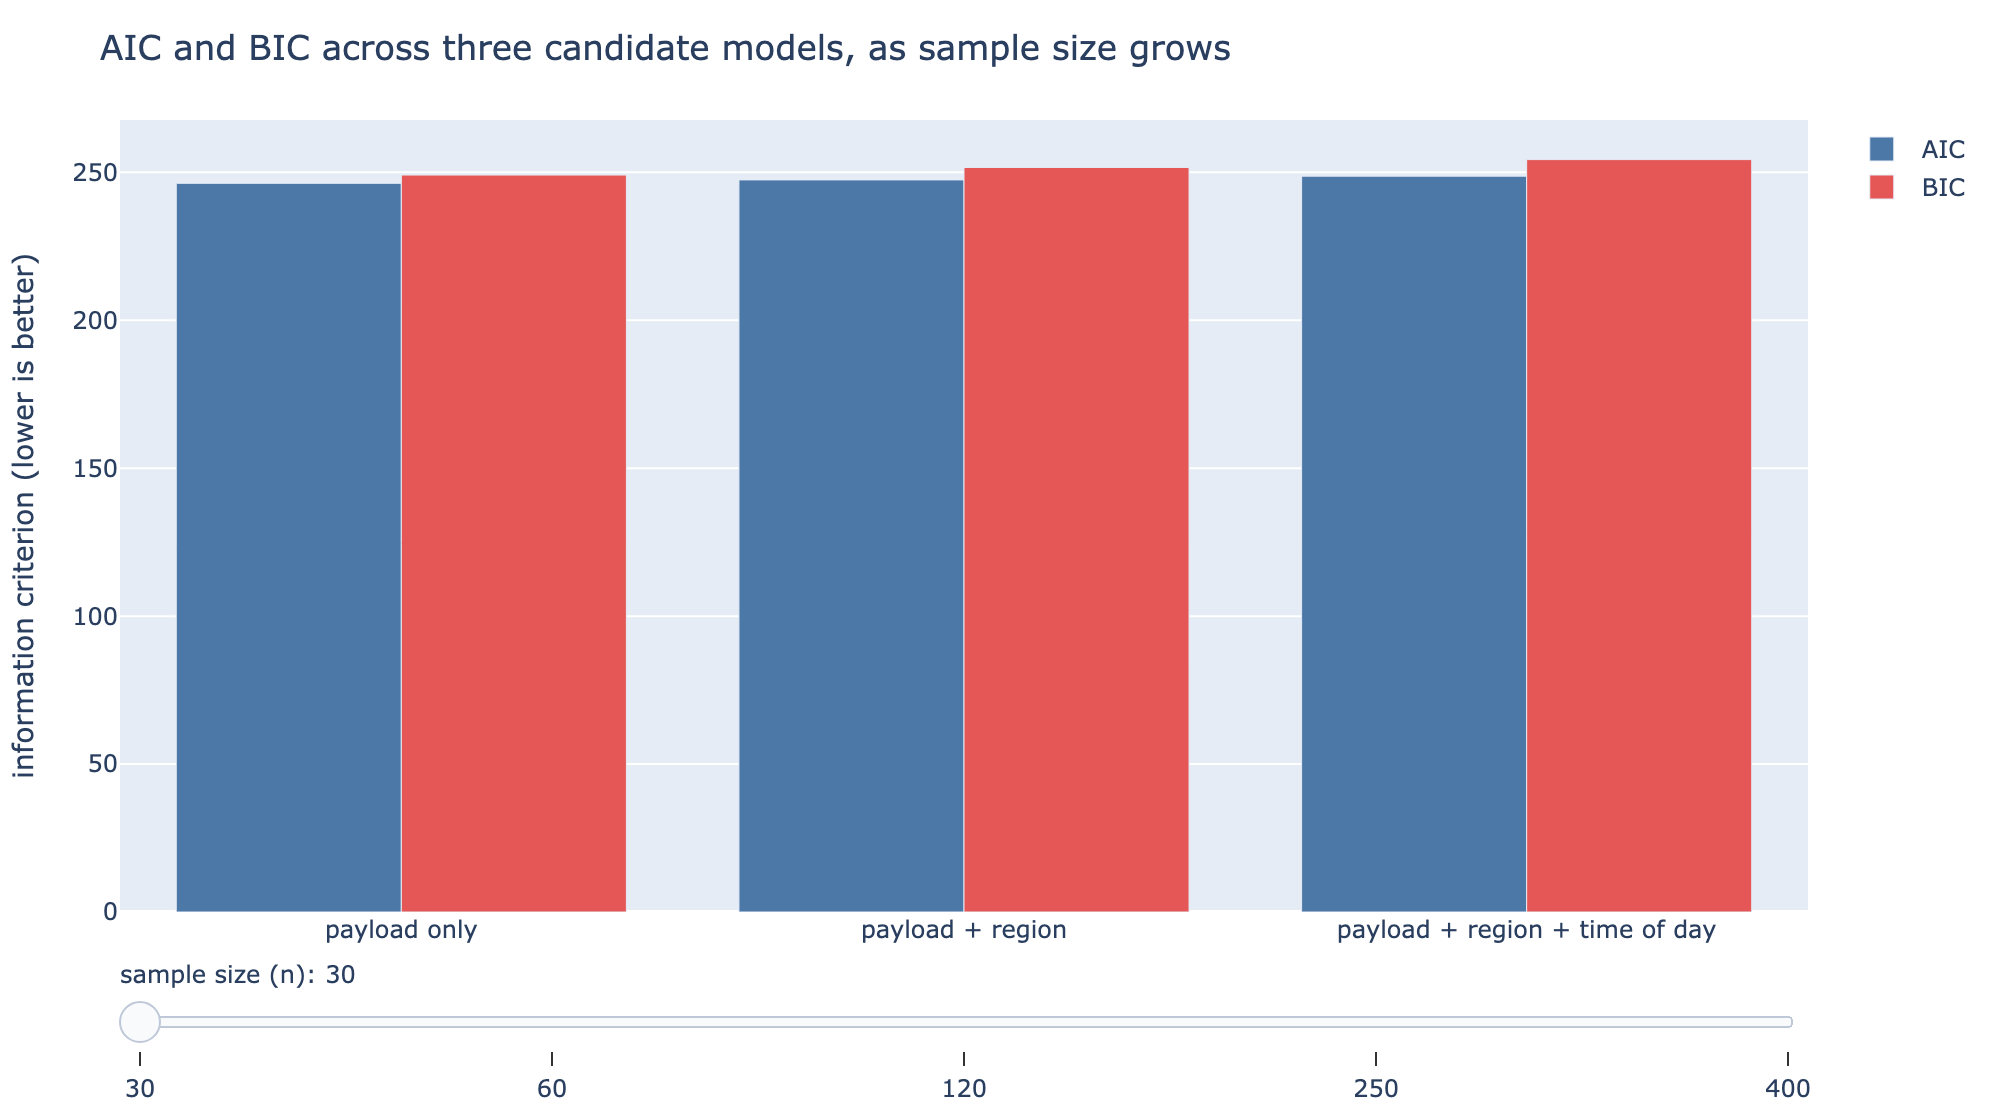

In [6]:
fig = FIGURES["chapter-04-fig-aic-bic"]()
fig

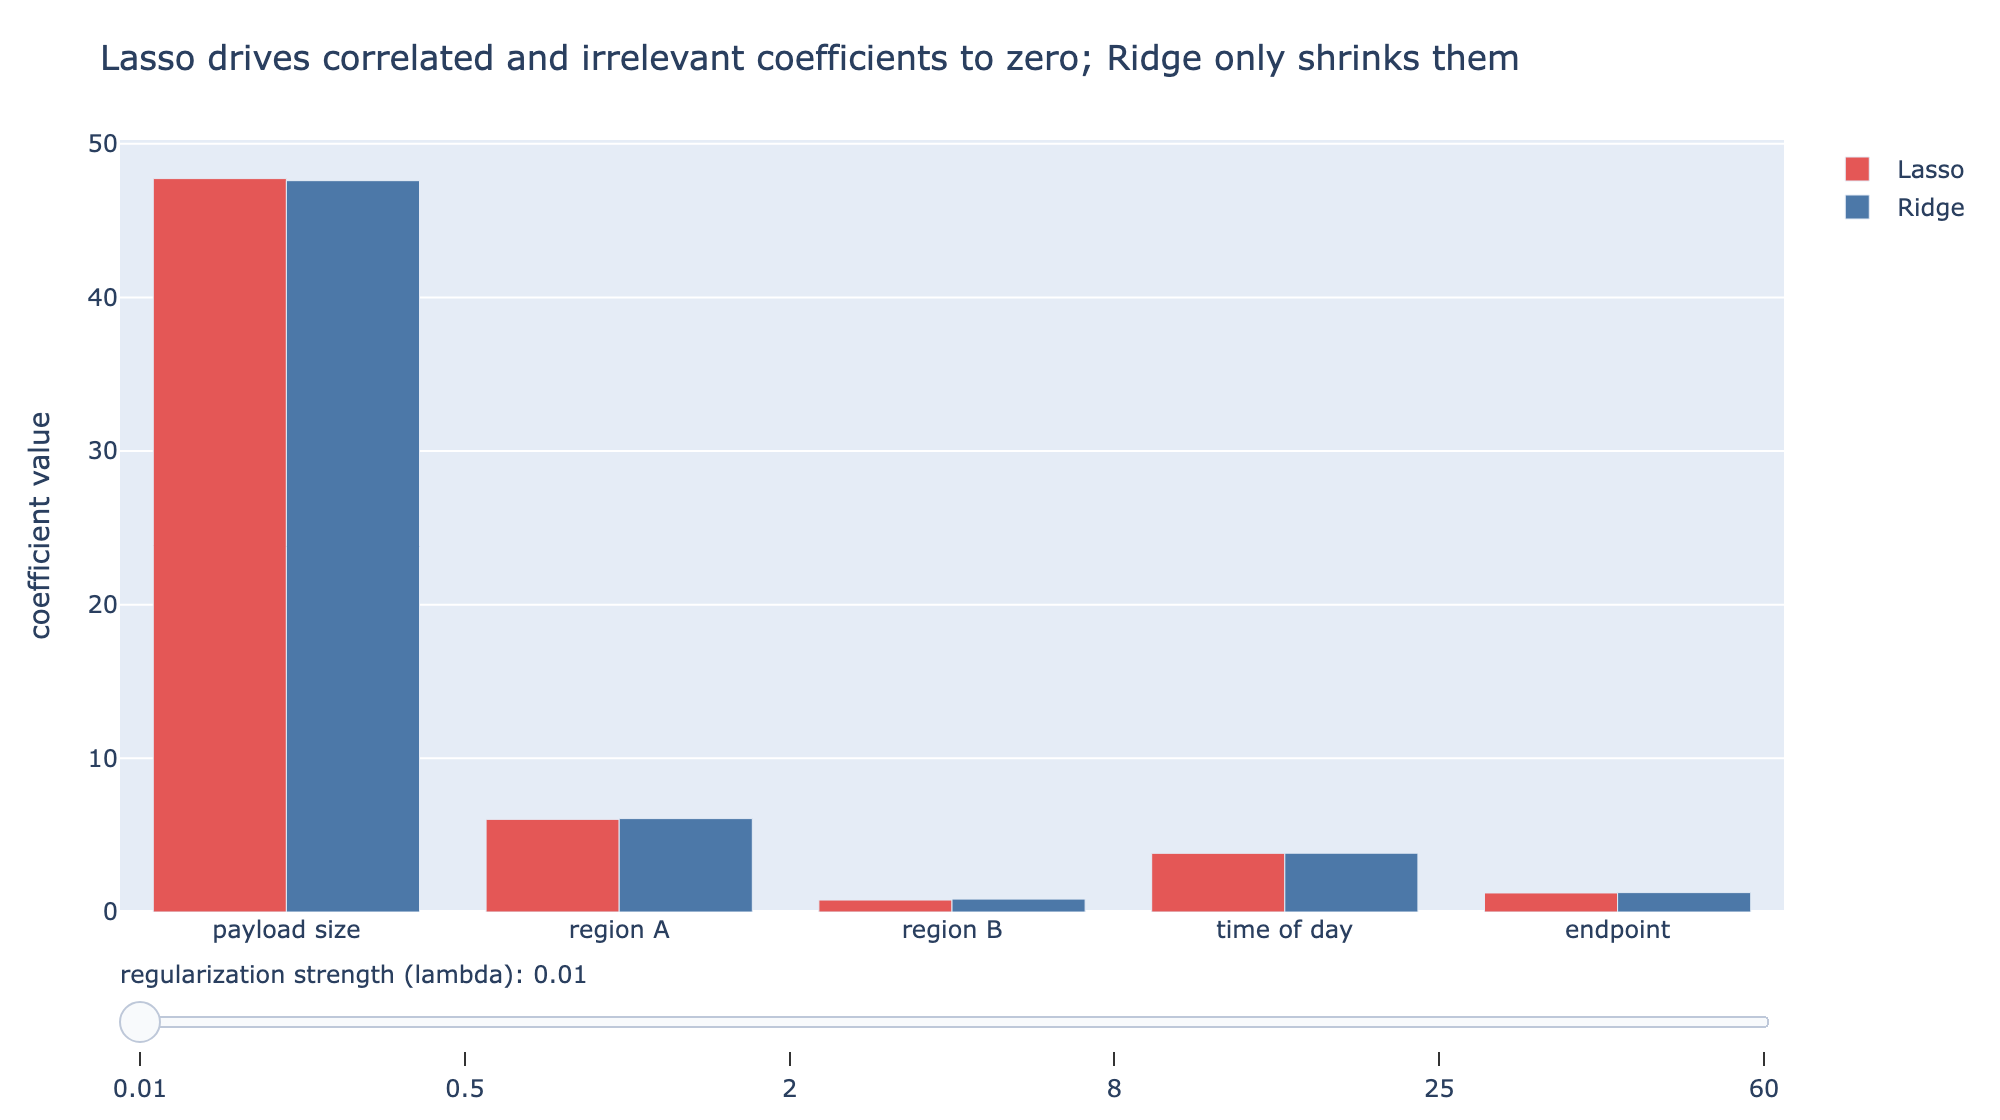

In [7]:
fig = FIGURES["chapter-04-fig-regularization-paths"]()
fig

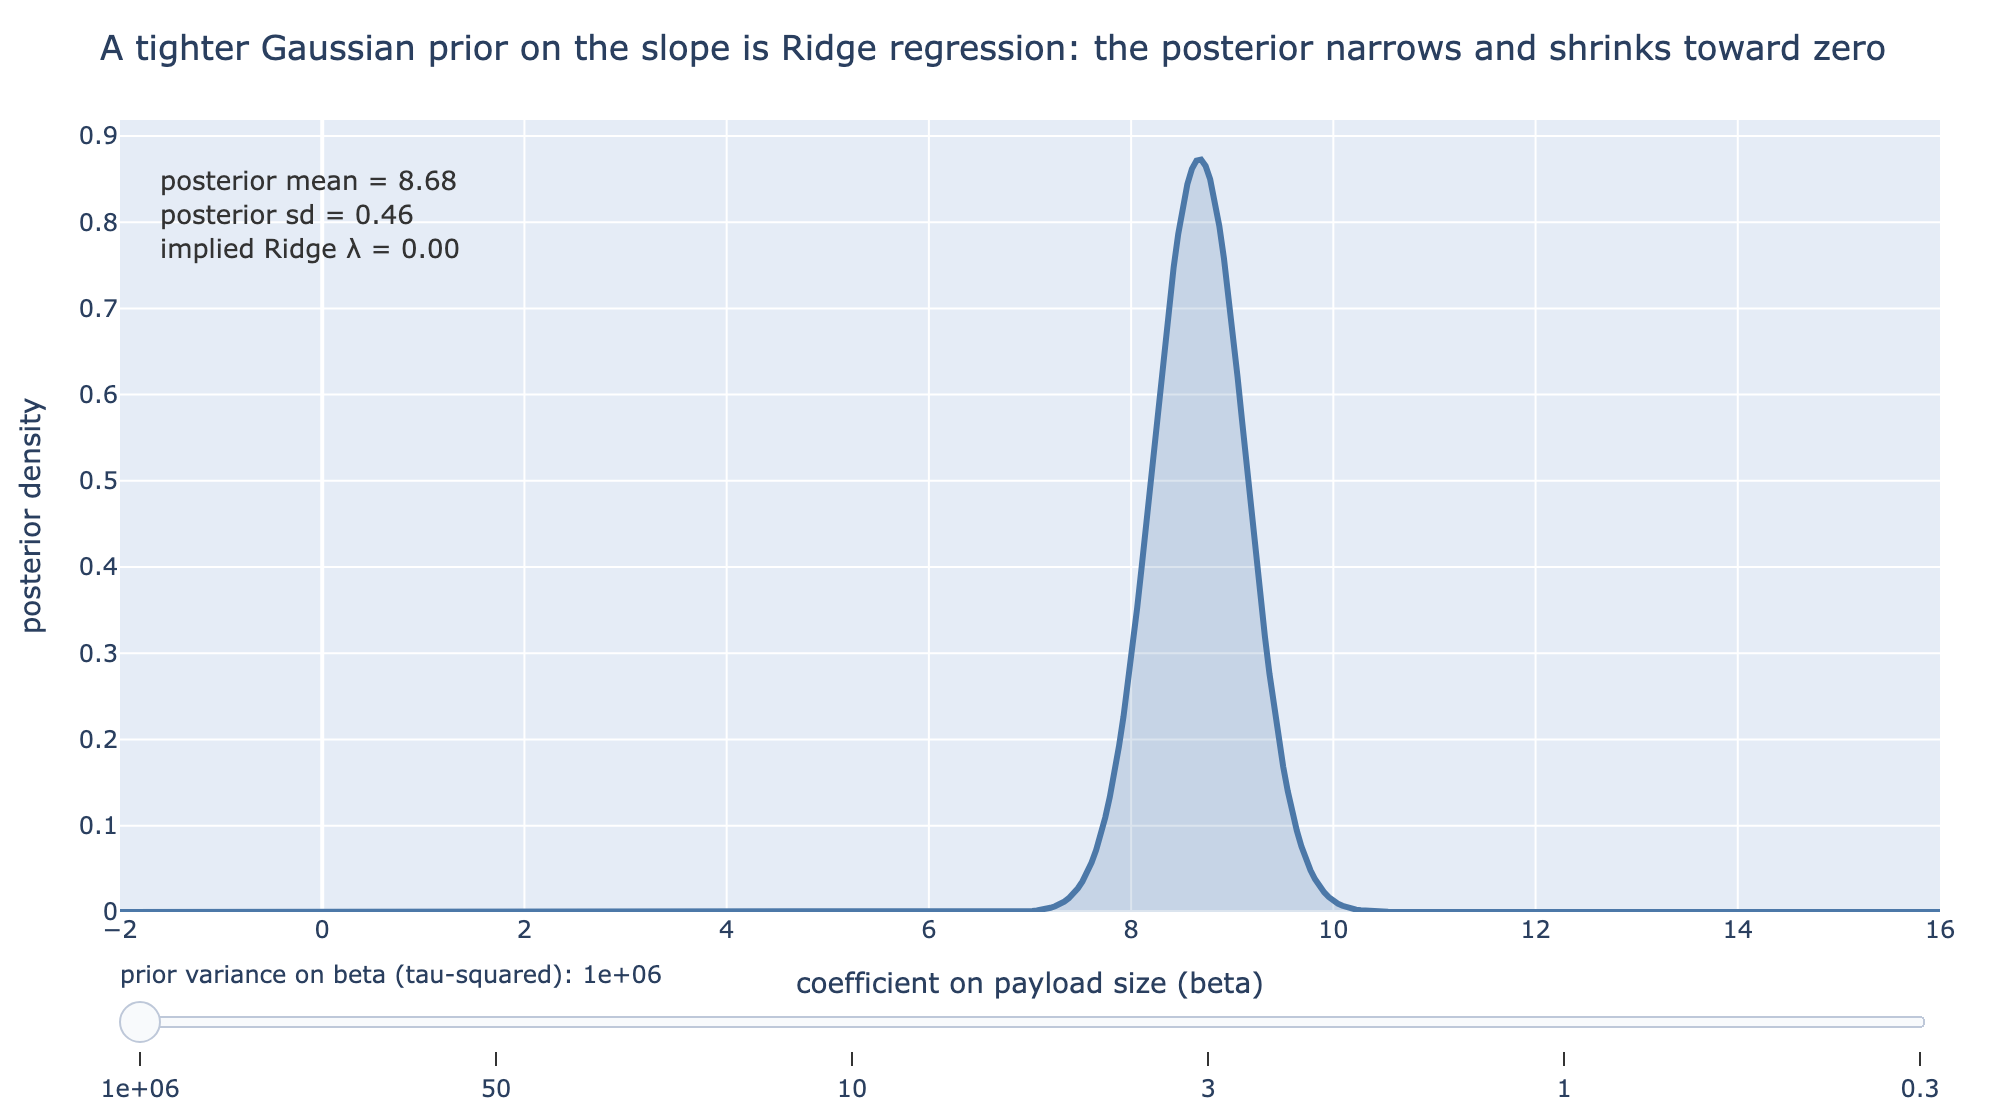

In [8]:
fig = FIGURES["chapter-04-fig-bayesian-ridge"]()
fig